In [3]:
import pandas as pd
import numpy as np

# 加载数据（记得改路径）
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 年龄缺失？用同客舱等级的中位数来填
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

print("数据大小（行，列）：", df.shape)
print("\n前3行长这样：")
print(df.head(3))


数据大小（行，列）： (891, 12)

前3行长这样：
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


In [4]:

# 按性别分组，计算存活率（0=死，1=活，平均值就是存活率）
sex_survival = df.groupby('Sex')['Survived'].mean()
print("\n不同性别存活率：")
print(sex_survival)



不同性别存活率：
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


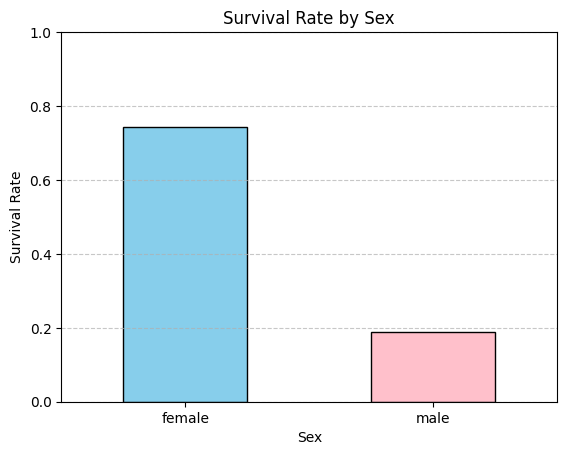


不同客舱等级存活率：
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [5]:

# 画图
sex_survival.plot(kind='bar', color=['skyblue', 'pink'], edgecolor='black')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 按客舱等级分组，计算存活率
pclass_survival = df.groupby('Pclass')['Survived'].mean()
print("\n不同客舱等级存活率：")
print(pclass_survival)


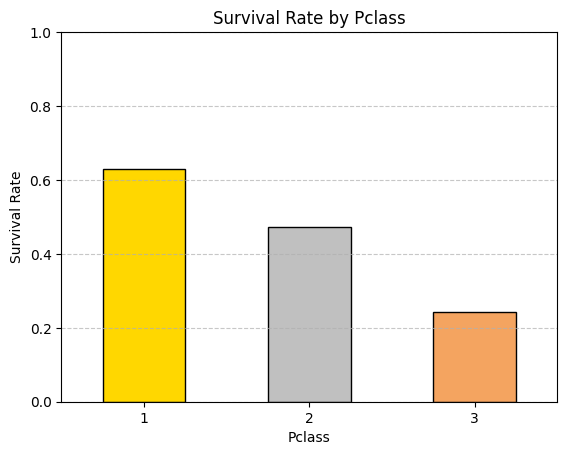

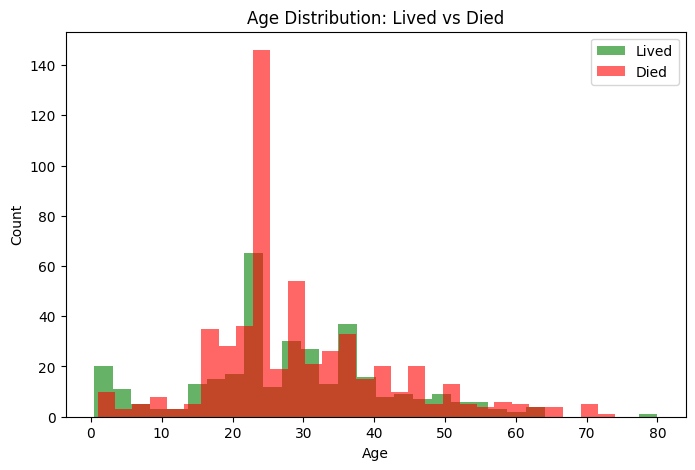


存活者平均年龄： 28.27388888888889
死亡者平均年龄： 29.560109289617486


In [6]:

# 画图
pclass_survival.plot(kind='bar', color=['gold', 'silver', 'sandybrown'], edgecolor='black')
plt.title('Survival Rate by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 切出存活的年龄列，和死亡的年龄列
age_lived = df[df['Survived'] == 1]['Age']
age_died = df[df['Survived'] == 0]['Age']

# 重叠直方图
plt.figure(figsize=(8,5))
plt.hist(age_lived, bins=30, alpha=0.6, label='Lived', color='green')
plt.hist(age_died, bins=30, alpha=0.6, label='Died', color='red')
plt.title('Age Distribution: Lived vs Died')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

# 平均年龄对比
print("\n存活者平均年龄：", age_lived.mean())
print("死亡者平均年龄：", age_died.mean())